# 📊 Exploratory Data Analysis (EDA)

## Business Sales Performance Analytics

##region_performance = (
    df.groupby("Region")[["Sales", "Profit"]]
      .sum()
      .sort_values(by="Sales", ascending=False)
)

region_performance# Objective

Analyze the cleaned sales dataset to identify revenue trends, product performance, regional profitability, and customer insights that can help businesses make informed decisions.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)

## Load the Cleaned Dataset

In [3]:
df = pd.read_csv("../processed_data/Superstore_Cleaned.csv")
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Year,Month,Month Number,Quarter
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,2016,November,11,4
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,2016,November,11,4
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,2016,June,6,2
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,2015,October,10,4
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,2015,October,10,4


## Dataset Overview

Load the cleaned dataset and verify its structure before performing business analysis.

In [7]:
df.shape

(9994, 25)

In [8]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit', 'Year',
       'Month', 'Month Number', 'Quarter'],
      dtype='str')

In [9]:
total_sales = df["Sales"].sum()
total_profit = df["Profit"].sum()
total_orders = df["Order ID"].nunique()
average_order_value = total_sales / total_orders

print(f"Total Sales: ${total_sales:,.2f}")
print(f"Total Profit: ${total_profit:,.2f}")
print(f"Total Orders: {total_orders}")
print(f"Average Order Value: ${average_order_value:,.2f}")

Total Sales: $2,297,200.86
Total Profit: $286,397.02
Total Orders: 5009
Average Order Value: $458.61


### Business Interpretation

The business generated **\$2,297,200.86** in total sales and **\$286,397.02** in profit across **5,009 unique orders**.

The **average order value** is **\$458.61**, indicating that customers spend approximately **\$459 per order**.

These KPIs provide a high-level summary of business performance and will be displayed as KPI cards in the final Power BI dashboard.

# Monthly Sales Trend

Understanding how sales change over time helps identify seasonal patterns, growth trends, and periods of high or low business performance.

In [13]:
monthly_sales = (
    df.groupby(["Year", "Month Number"])["Sales"]
      .sum()
      .reset_index()
)

monthly_sales["Date"] = pd.to_datetime(
    monthly_sales["Year"].astype(str) + "-" +
    monthly_sales["Month Number"].astype(str) + "-01"
)

monthly_sales = monthly_sales.sort_values("Date")

monthly_sales.head()

,Year,Month Number,Sales,Date
0,2014,1,14236.895,2014-01-01
1,2014,2,4519.892,2014-02-01
2,2014,3,55691.009,2014-03-01
3,2014,4,28295.345,2014-04-01
4,2014,5,23648.287,2014-05-01


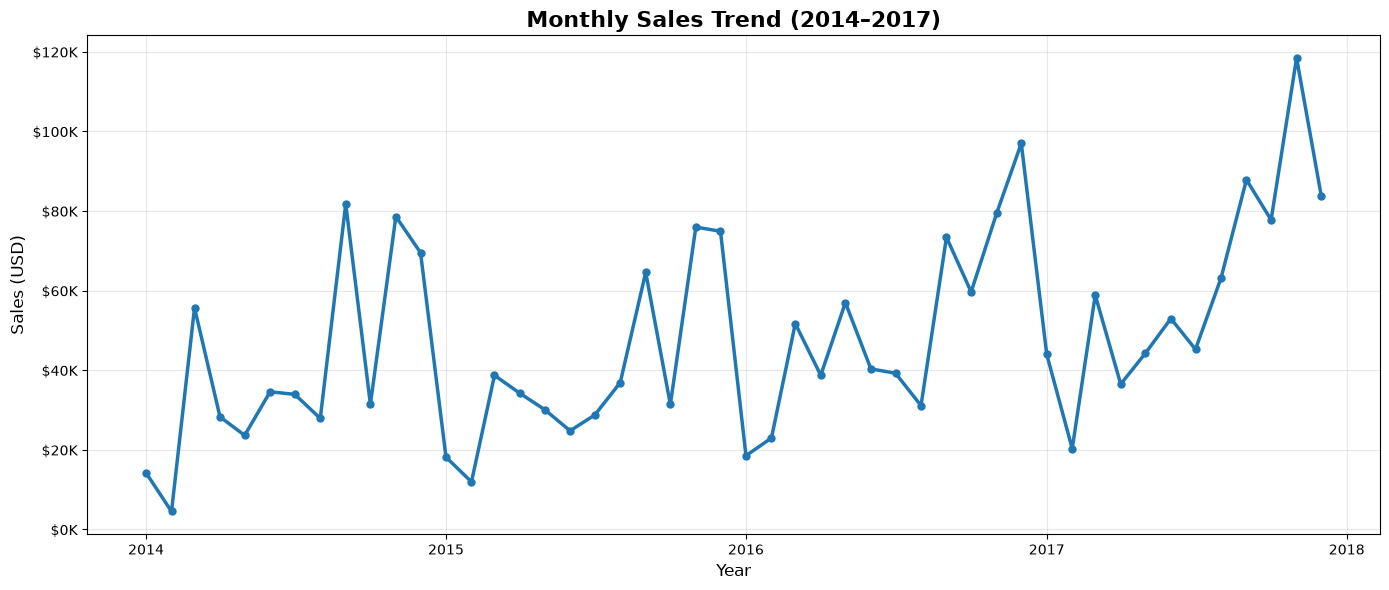

In [16]:
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import matplotlib.dates as mdates

plt.figure(figsize=(14, 6))

plt.plot(
    monthly_sales["Date"],
    monthly_sales["Sales"],
    marker="o",
    markersize=5,
    linewidth=2.5
)

plt.title("Monthly Sales Trend (2014–2017)", fontsize=16, weight="bold")
plt.xlabel("Year", fontsize=12)
plt.ylabel("Sales (USD)", fontsize=12)

# Show only one tick per year
plt.gca().xaxis.set_major_locator(mdates.YearLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

# Format y-axis as currency in thousands
plt.gca().yaxis.set_major_formatter(
    FuncFormatter(lambda x, _: f'${x/1000:.0f}K')
)

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig("../images/monthly_sales_trend.png", dpi=300)

plt.show()

### Business Interpretation

The monthly sales trend shows that sales fluctuate throughout the year, indicating periods of both high and low customer demand. Despite these fluctuations, the overall sales performance improves over time, with 2017 recording the highest monthly sales compared to previous years.

The noticeable increase in sales during the later months suggests that the business experienced growth in customer demand, successful marketing efforts, or seasonal sales peaks. Understanding these patterns can help the business prepare inventory, allocate resources efficiently, and plan promotional campaigns during high-demand periods.

### Recommendation

- Investigate the factors contributing to high-sales months and replicate those strategies throughout the year.
- Plan inventory and staffing based on seasonal demand to avoid stock shortages or overstocking.
- Launch targeted promotional campaigns during historically low-performing months to improve sales consistency.
- Analyze customer purchasing behavior during peak periods to identify opportunities for repeat sales and customer retention.

# Top 10 Products by Sales

Identifying the highest-selling products helps businesses understand which items contribute the most revenue and where to focus marketing, inventory, and pricing strategies.

In [17]:
top_products = (
    df.groupby("Product Name")["Sales"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

top_products

Product Name
Canon imageCLASS 2200 Advanced Copier                                          61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind    27453.384
Cisco TelePresence System EX90 Videoconferencing Unit                          22638.480
HON 5400 Series Task Chairs for Big and Tall                                   21870.576
GBC DocuBind TL300 Electric Binding System                                     19823.479
GBC Ibimaster 500 Manual ProClick Binding System                               19024.500
Hewlett Packard LaserJet 3310 Copier                                           18839.686
HP Designjet T520 Inkjet Large Format Printer - 24" Color                      18374.895
GBC DocuBind P400 Electric Binding System                                      17965.068
High Speed Automatic Electric Letter Opener                                    17030.312
Name: Sales, dtype: float64

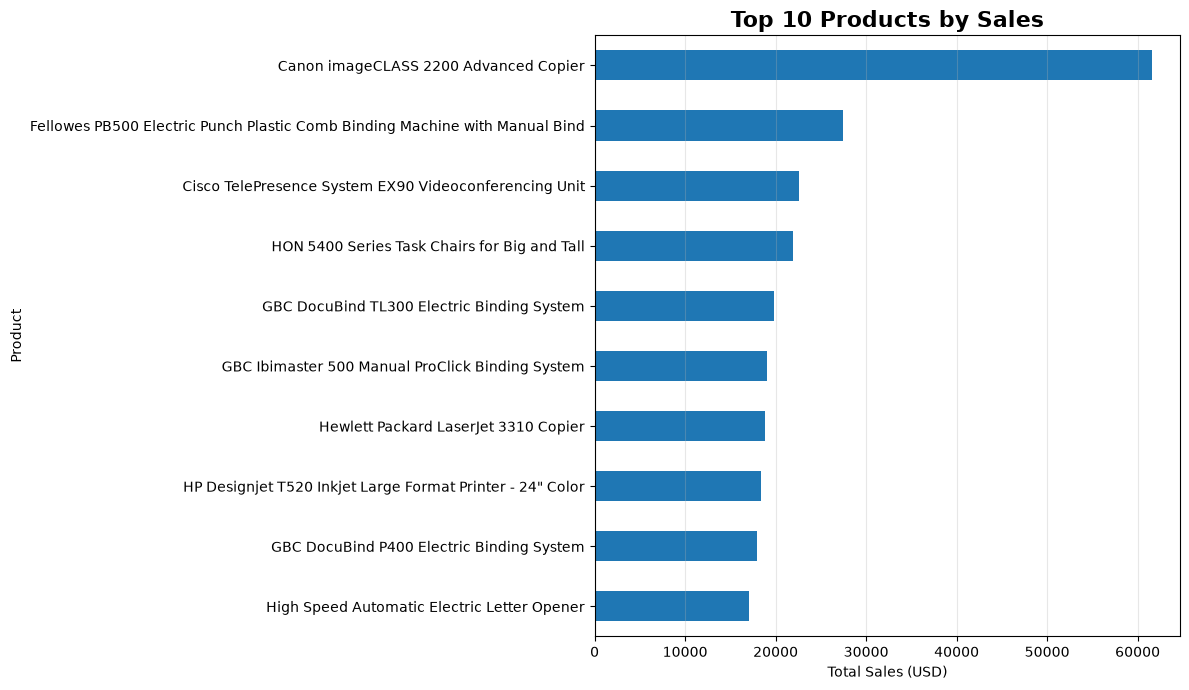

In [18]:
plt.figure(figsize=(12, 7))

top_products.sort_values().plot(kind="barh")

plt.title("Top 10 Products by Sales", fontsize=16, weight="bold")
plt.xlabel("Total Sales (USD)")
plt.ylabel("Product")

plt.grid(axis="x", alpha=0.3)

plt.tight_layout()

plt.savefig("../images/top_10_products.png", dpi=300)

plt.show()

### Business Interpretation

The analysis highlights the products that contribute the highest revenue to the business. A relatively small number of products account for a significant share of total sales, indicating that these items are key revenue drivers.

Monitoring the performance of these products is essential, as changes in their demand could have a substantial impact on overall business revenue.

### Recommendation

- Maintain sufficient inventory for the highest-selling products.
- Prioritize these products in marketing campaigns and promotions.
- Analyze why these products perform well and apply similar strategies to lower-performing products.
- Continuously monitor demand to avoid stock shortages during peak sales periods.

# Sales by Category

Analyzing sales across product categories helps identify which areas of the business contribute the most revenue and where future investments should be focused.

In [19]:
category_sales = (
    df.groupby("Category")["Sales"]
      .sum()
      .sort_values(ascending=False)
)

category_sales

Category
Technology         836154.0330
Furniture          741999.7953
Office Supplies    719047.0320
Name: Sales, dtype: float64

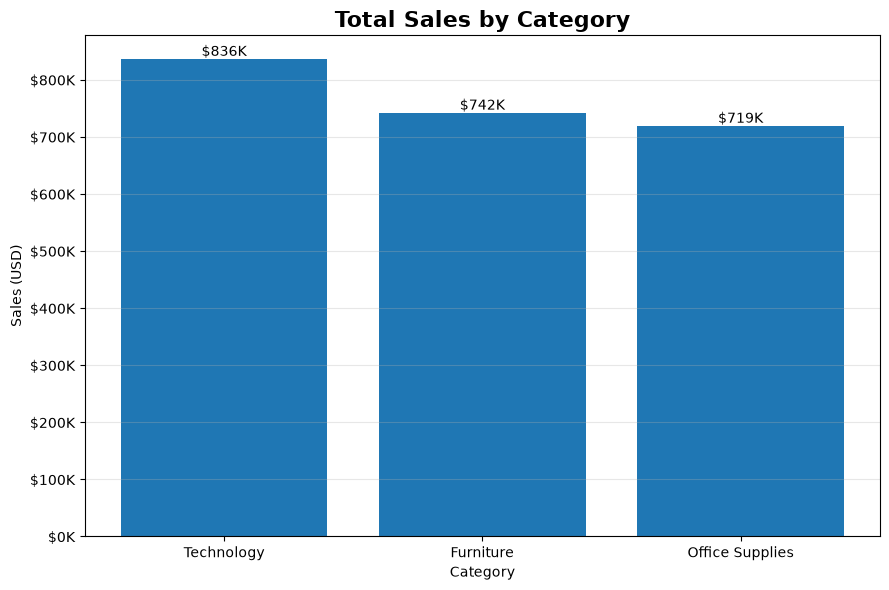

In [20]:
from matplotlib.ticker import FuncFormatter

plt.figure(figsize=(9,6))

bars = plt.bar(
    category_sales.index,
    category_sales.values
)

plt.title("Total Sales by Category", fontsize=16, weight="bold")
plt.xlabel("Category")
plt.ylabel("Sales (USD)")

plt.gca().yaxis.set_major_formatter(
    FuncFormatter(lambda x, _: f'${x/1000:.0f}K')
)

plt.grid(axis="y", alpha=0.3)

# Add value labels
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f'${height/1000:.0f}K',
        ha='center',
        va='bottom',
        fontsize=10
    )

plt.tight_layout()

plt.savefig("../images/sales_by_category.png", dpi=300)

plt.show()

### Business Interpretation

The category analysis shows that not all product categories contribute equally to total sales. Identifying the highest-performing category enables the business to allocate marketing budgets, inventory, and operational resources more effectively.

Categories with comparatively lower sales may require additional promotional efforts or product portfolio evaluation to improve their performance.

### Recommendation

- Continue investing in high-performing categories to maximize revenue.
- Review pricing, promotions, and product assortment for lower-performing categories.
- Use customer purchasing trends to identify opportunities for cross-selling products from different categories.

# Profit by Category

While sales indicate revenue generation, profit reveals the actual financial contribution of each product category. Comparing profits across categories helps identify the most valuable business segments.

In [21]:
category_profit = (
    df.groupby("Category")["Profit"]
      .sum()
      .sort_values(ascending=False)
)

category_profit

Category
Technology         145454.9481
Office Supplies    122490.8008
Furniture           18451.2728
Name: Profit, dtype: float64

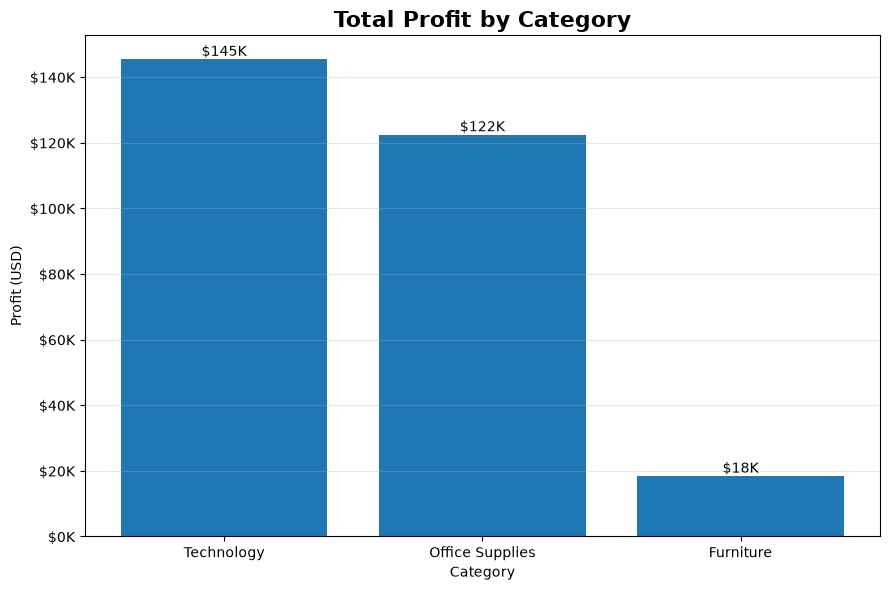

In [22]:
plt.figure(figsize=(9,6))

bars = plt.bar(
    category_profit.index,
    category_profit.values
)

plt.title("Total Profit by Category", fontsize=16, weight="bold")
plt.xlabel("Category")
plt.ylabel("Profit (USD)")

plt.gca().yaxis.set_major_formatter(
    FuncFormatter(lambda x, _: f'${x/1000:.0f}K')
)

plt.grid(axis="y", alpha=0.3)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f'${height/1000:.0f}K',
        ha='center',
        va='bottom',
        fontsize=10
    )

plt.tight_layout()

plt.savefig("../images/profit_by_category.png", dpi=300)

plt.show()

### Business Interpretation

Profitability varies across product categories, indicating that higher sales do not always translate into higher profits. Identifying the most profitable categories enables the business to focus on areas that maximize financial returns rather than revenue alone.

### Recommendation

- Prioritize investment in categories that consistently generate high profits.
- Evaluate pricing strategies and operational costs for lower-profit categories.
- Balance sales growth with profitability to ensure sustainable business performance.

# Regional Performance Analysis

Analyzing sales and profit across different regions helps identify high-performing markets and areas that may require additional business attention. This enables better resource allocation and regional growth strategies.

In [23]:
region_performance = (
    df.groupby("Region")[["Sales", "Profit"]]
      .sum()
      .sort_values(by="Sales", ascending=False)
)

region_performance

,Sales,Profit
Region,,
West,725457.8245,108418.4489
East,678781.2400,91522.7800
Central,501239.8908,39706.3625
South,391721.9050,46749.4303


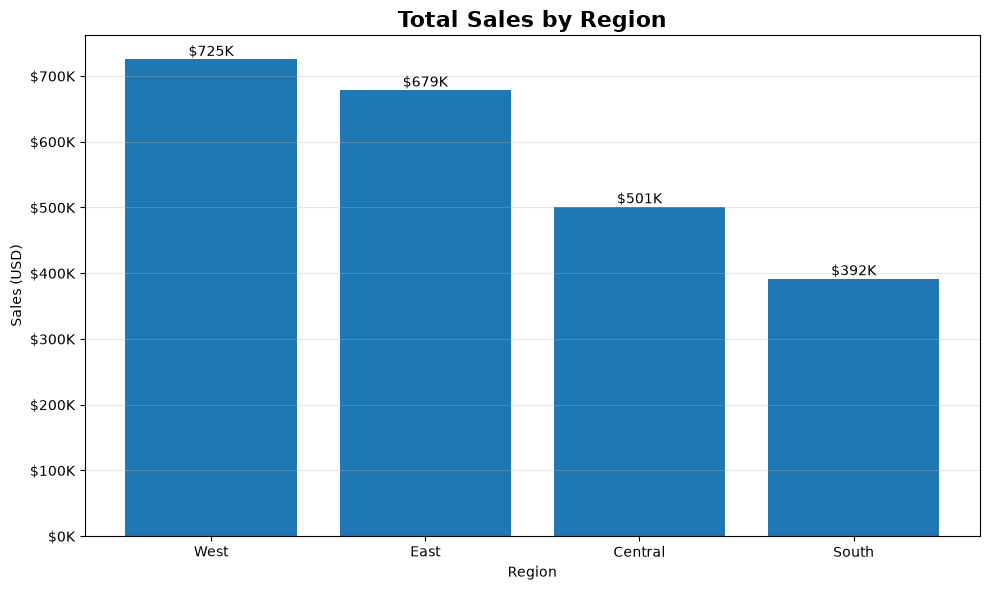

In [24]:
plt.figure(figsize=(10,6))

bars = plt.bar(
    region_performance.index,
    region_performance["Sales"]
)

plt.title("Total Sales by Region", fontsize=16, weight="bold")
plt.xlabel("Region")
plt.ylabel("Sales (USD)")

plt.gca().yaxis.set_major_formatter(
    FuncFormatter(lambda x, _: f'${x/1000:.0f}K')
)

plt.grid(axis="y", alpha=0.3)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x()+bar.get_width()/2,
        height,
        f'${height/1000:.0f}K',
        ha="center",
        va="bottom"
    )

plt.tight_layout()

plt.savefig("../images/sales_by_region.png", dpi=300)

plt.show()

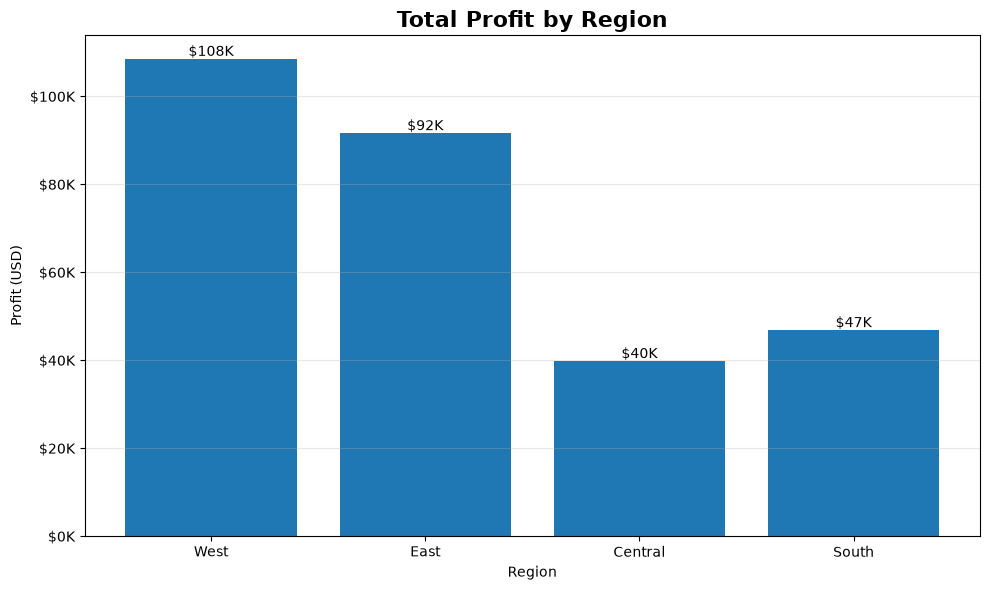

In [25]:
plt.figure(figsize=(10,6))

bars = plt.bar(
    region_performance.index,
    region_performance["Profit"]
)

plt.title("Total Profit by Region", fontsize=16, weight="bold")
plt.xlabel("Region")
plt.ylabel("Profit (USD)")

plt.gca().yaxis.set_major_formatter(
    FuncFormatter(lambda x, _: f'${x/1000:.0f}K')
)

plt.grid(axis="y", alpha=0.3)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x()+bar.get_width()/2,
        height,
        f'${height/1000:.0f}K',
        ha="center",
        va="bottom"
    )

plt.tight_layout()

plt.savefig("../images/profit_by_region.png", dpi=300)

plt.show()

### Business Interpretation

Regional analysis highlights differences in both revenue generation and profitability. Some regions contribute significantly more to overall business performance, while others present opportunities for improvement.

Comparing sales and profit together helps determine whether strong sales are translating into healthy financial returns.

### Recommendation

- Focus marketing and expansion efforts on regions with consistently high sales and profit.
- Investigate lower-performing regions to identify operational, pricing, or customer-related challenges.
- Replicate successful strategies from top-performing regions across other markets where appropriate.

## Customer Segment Analysis

Customer segmentation helps identify which group of customers contributes the most to business revenue and profitability. This information can guide marketing strategies, customer retention efforts, and resource allocation.

In [26]:
segment_performance = (
    df.groupby("Segment")[["Sales", "Profit"]]
      .sum()
      .sort_values(by="Sales", ascending=False)
)

segment_performance

,Sales,Profit
Segment,,
Consumer,1.161401e+06,134119.2092
Corporate,7.061464e+05,91979.1340
Home Office,4.296531e+05,60298.6785


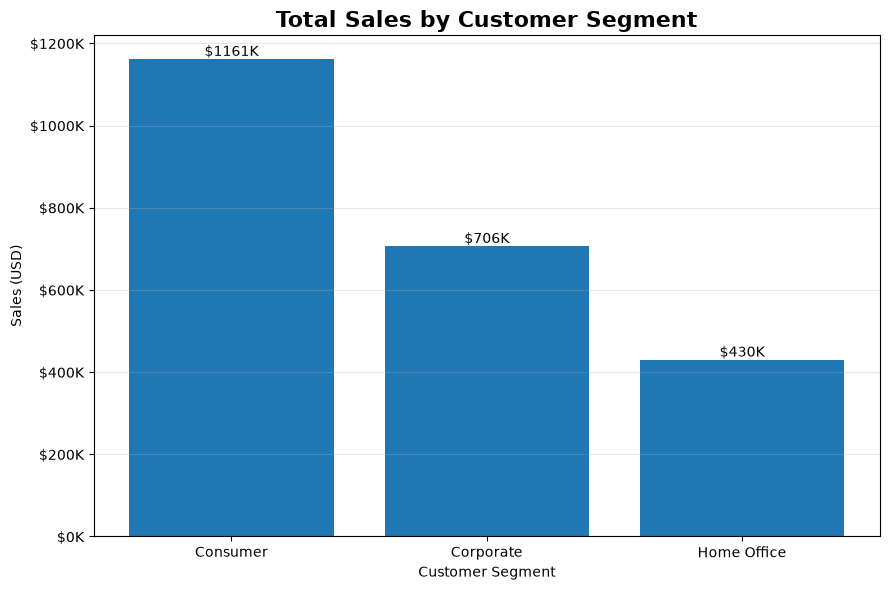

In [28]:
plt.figure(figsize=(9,6))

bars = plt.bar(
    segment_performance.index,
    segment_performance["Sales"]
)

plt.title("Total Sales by Customer Segment", fontsize=16, weight="bold")
plt.xlabel("Customer Segment")
plt.ylabel("Sales (USD)")

plt.gca().yaxis.set_major_formatter(
    FuncFormatter(lambda x, _: f'${x/1000:.0f}K')
)

plt.grid(axis="y", alpha=0.3)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x()+bar.get_width()/2,
        height,
        f'${height/1000:.0f}K',
        ha="center",
        va="bottom"
    )

plt.tight_layout()

plt.savefig("../images/sales_by_segment.png", dpi=300)

plt.show()

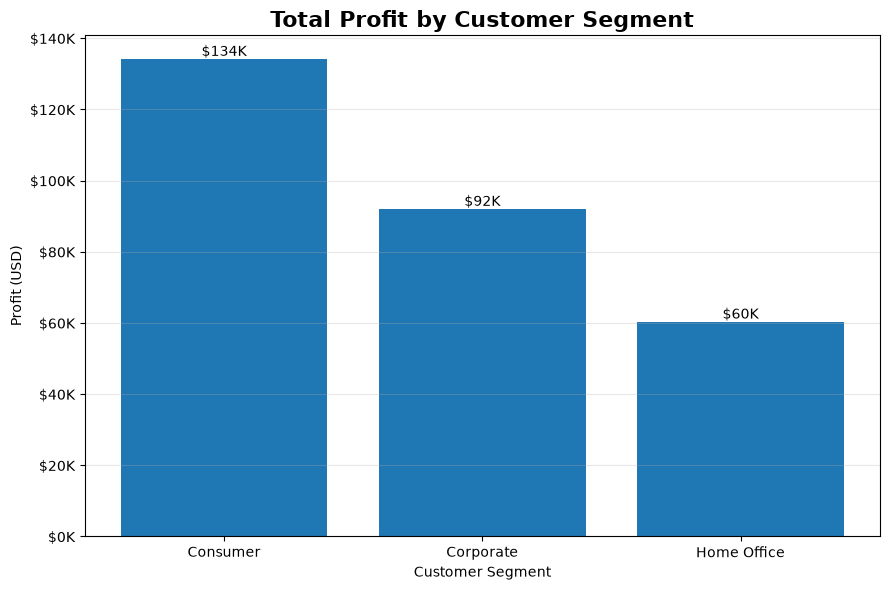

In [30]:
plt.figure(figsize=(9,6))

bars = plt.bar(
    segment_performance.index,
    segment_performance["Profit"]
)

plt.title("Total Profit by Customer Segment", fontsize=16, weight="bold")
plt.xlabel("Customer Segment")
plt.ylabel("Profit (USD)")

plt.gca().yaxis.set_major_formatter(
    FuncFormatter(lambda x, _: f'${x/1000:.0f}K')
)

plt.grid(axis="y", alpha=0.3)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x()+bar.get_width()/2,
        height,
        f'${height/1000:.0f}K',
        ha="center",
        va="bottom"
    )

plt.tight_layout()

plt.savefig("../images/profit_by_segment.png", dpi=300)

plt.show()

### Business Interpretation

The customer segment analysis reveals how different customer groups contribute to overall sales and profitability. Understanding these differences enables the business to tailor marketing strategies, improve customer retention, and prioritize high-value customer segments.

Comparing both sales and profit ensures that decisions are based on customer value rather than revenue alone.

### Recommendation

- Strengthen engagement with the most profitable customer segment through loyalty programs and targeted marketing.
- Develop customized promotions for lower-performing segments to increase their contribution.
- Monitor customer purchasing patterns regularly to optimize marketing investments and maximize customer lifetime value.

# Discount vs Profit Analysis

Discounts are commonly used to increase sales, but excessive discounts can reduce profitability. This analysis explores the relationship between discounts and profit to evaluate whether current discount strategies are financially sustainable.

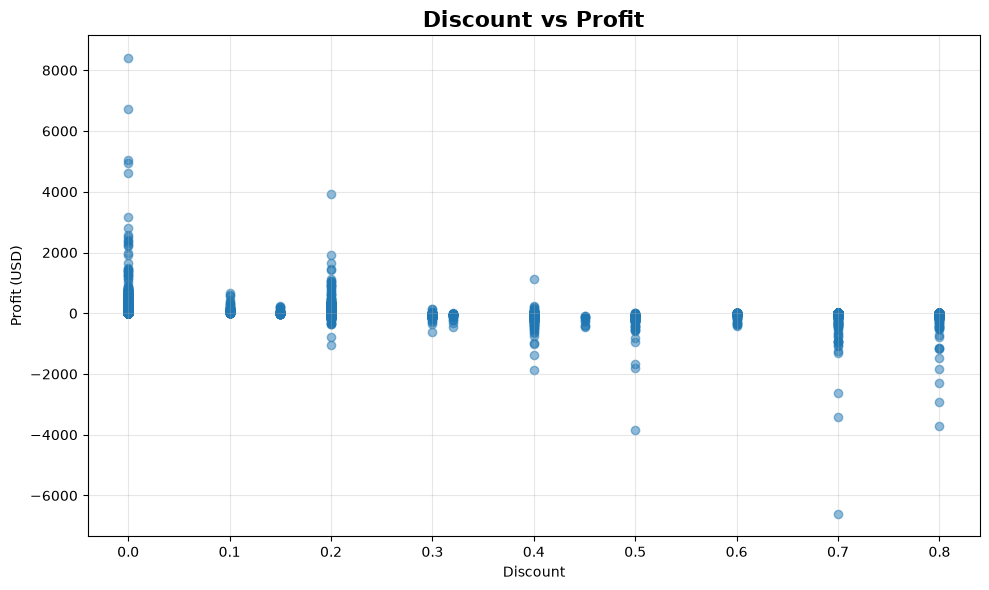

In [31]:
plt.figure(figsize=(10,6))

plt.scatter(
    df["Discount"],
    df["Profit"],
    alpha=0.5
)

plt.title("Discount vs Profit", fontsize=16, weight="bold")
plt.xlabel("Discount")
plt.ylabel("Profit (USD)")

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig("../images/discount_vs_profit.png", dpi=300)

plt.show()

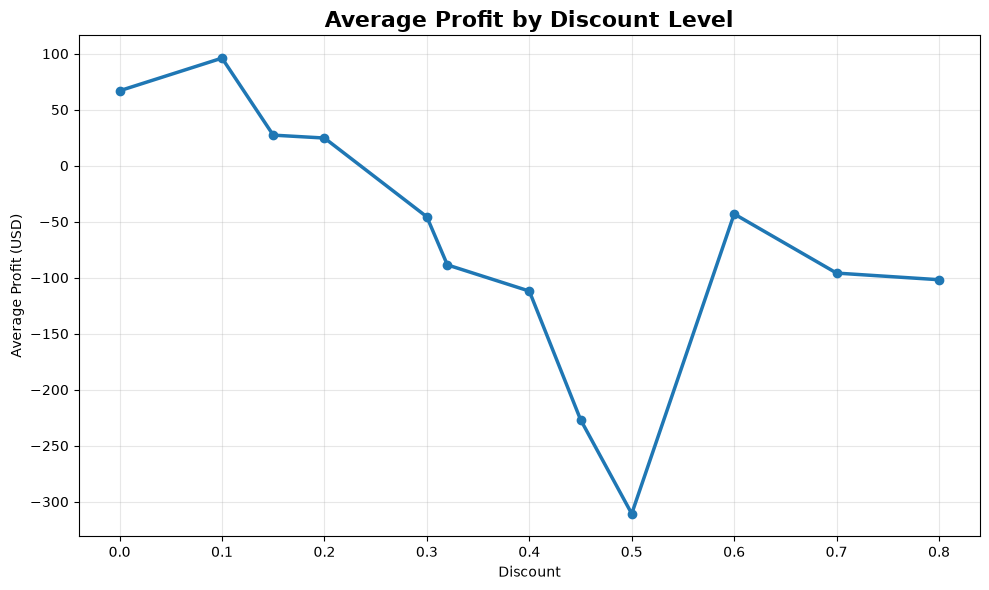

In [32]:
discount_analysis = (
    df.groupby("Discount")["Profit"]
      .mean()
      .reset_index()
)

plt.figure(figsize=(10,6))

plt.plot(
    discount_analysis["Discount"],
    discount_analysis["Profit"],
    marker="o",
    linewidth=2.5
)

plt.title("Average Profit by Discount Level", fontsize=16, weight="bold")
plt.xlabel("Discount")
plt.ylabel("Average Profit (USD)")

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig("../images/average_profit_by_discount.png", dpi=300)

plt.show()

In [33]:
df.to_csv("../processed_data/Superstore_Final.csv", index=False)

print("Final dataset exported successfully!")

Final dataset exported successfully!
